In [11]:
import pandas as pd

df = pd.read_csv("http://114.207.245.181:13000/csv/iris01.csv")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [13]:
# 컬럼명 변경하기
t1 = {
    'sepal_length' : '꽃받침길이',
    'sepal_width' : '꽃받침넓이',
    'petal_length' : '꽃잎길이',
    'petal_width' : '꽃잎넓이',
    'species' : '종류'
}

df.rename(columns=t1, inplace=True)

In [14]:
df.dtypes

꽃받침길이    float64
꽃받침넓이    float64
꽃잎길이     float64
꽃잎넓이     float64
종류        object
dtype: object

In [15]:
df['종류'].value_counts()

종류
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

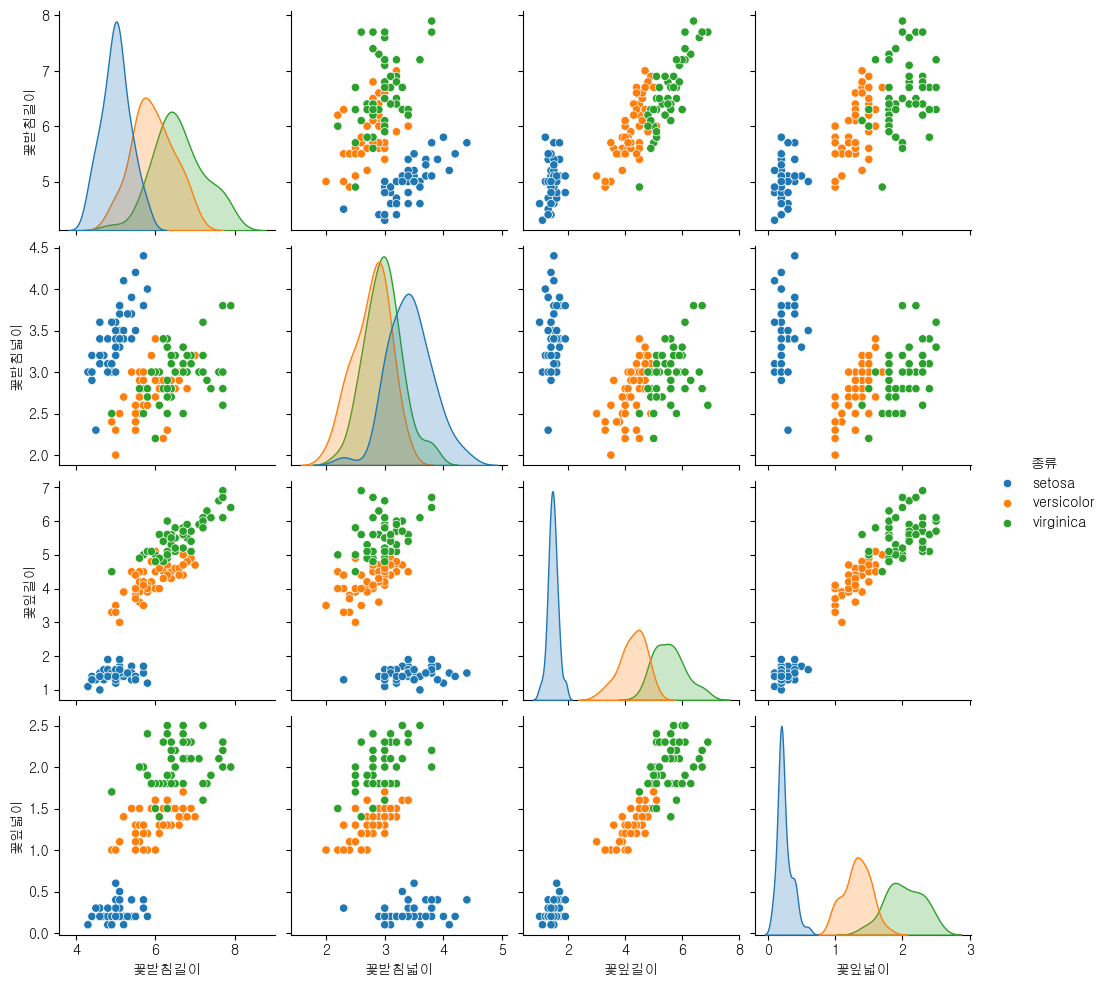

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc

rc('font', family='Gulim')

sns.pairplot(data=df, hue='종류')
plt.show()

In [17]:
# 종류 setosa => 0, versicolor => 1, virginica => 2
t1 = {'setosa' : 0, 'versicolor' : 1, 'virginica' : 2}
df['종류'] = df['종류'].map(t1)
df

,꽃받침길이,꽃받침넓이,꽃잎길이,꽃잎넓이,종류
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [18]:
df['종류'] = df['종류'].astype('int64')
df.dtypes

꽃받침길이    float64
꽃받침넓이    float64
꽃잎길이     float64
꽃잎넓이     float64
종류         int64
dtype: object

In [19]:
x = df[ df.columns[:-1] ].values
y = df['종류'].values
x.shape, y.shape

((150, 4), (150,))

In [28]:
x_train[:5]

array([[7.4, 2.8, 6.1, 1.9],
       [6. , 2.2, 5. , 1.5],
       [4.7, 3.2, 1.6, 0.2],
       [5.1, 3.5, 1.4, 0.2],
       [6. , 2.2, 4. , 1. ]])

In [21]:
# 8:2로 분할하기
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=123)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((120, 4), (30, 4), (120,), (30,))

In [22]:
# StandardScaler 적용하기
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaler.fit(x_train)

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train_scaled.shape, x_test_scaled.shape

((120, 4), (30, 4))

In [23]:
x_train_scaled[:5]

array([[ 1.89107197, -0.54902995,  1.32384841,  0.91546477],
       [ 0.16162128, -1.91685543,  0.68491609,  0.37363605],
       [-1.44429721,  0.3628537 , -1.28996563, -1.38730727],
       [-0.95016844,  1.04676645, -1.40613514, -1.38730727],
       [ 0.16162128, -1.91685543,  0.10406852, -0.30364984]])

In [24]:
# 모델 생성 및 학습
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

model.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [25]:
# 모델 정확도 score 확인
model.score(x_train_scaled, y_train), model.score(x_test_scaled, y_test)

(0.9833333333333333, 0.9666666666666667)

In [ ]:
y_pred = model.predict(x_test_scaled)
y_pred, y_test

(array([1, 2, 2, 1, 0, 2, 1, 0, 0, 1, 2, 0, 1, 2, 2, 2, 0, 0, 1, 0, 0, 1,
        0, 2, 0, 0, 0, 2, 2, 0]),
 array([1, 2, 2, 1, 0, 2, 1, 0, 0, 1, 2, 0, 1, 2, 2, 2, 0, 0, 1, 0, 0, 2,
        0, 2, 0, 0, 0, 2, 2, 0]))

In [32]:
# 모델 저장하기
import joblib
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', scaler),
    ('model', model)
])

joblib.dump(pipe, './pkl/20260526_model.joblib')

['./pkl/20260526_model.joblib']

In [4]:
import joblib
pipe = joblib.load('./pkl/20260526_model.joblib')

In [5]:
import numpy as np
sample = np.array([[5.1, 3.5, 1.4, 0.2]])
pipe.predict(sample)

array([0])